# Test UFD detection pipeline

In [24]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
sys.path.append('/home/jiaxuanl/Research/Packages/simple')
sys.path.append('/home/jiaxuanl/Research/Roman_Cycle1/')


from scipy.stats import binned_statistic
import kuaizi
kuaizi.set_matplotlib(style='nature', usetex=False, dpi=90)

import simple
import example
# from example import setup_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate star and galaxy catalog

In [2]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
os.environ['ROSESIM_DATA_PATH'] = "/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/"
import artpop
import rosesim
from rosesim.display import show_image_wcs
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

DATA_PATH = rosesim.DATA_PATH

log_m_star = 4
gal_kwargs = {'age': (10**9.6) * u.yr,
              'feh': -2,
              'total_mass': 10**log_m_star,
              'r_eff': 10**rosesim.mass_size_carlsten(log_m_star) / 1000 * u.kpc,
              'distance': 3 * u.Mpc}

gal = RomanGalaxy(prefix=f'dw_1e{log_m_star:.1f}_{gal_kwargs["distance"].to(u.Mpc).value:.1f}Mpc_age{np.log10(gal_kwargs["age"].value):.1f}_feh{gal_kwargs["feh"]:.1f}', data_dir=DATA_PATH)

reff = (gal_kwargs['r_eff'] / gal_kwargs['distance']).cgs.value * 206265
print('R_eff [arcsec]', reff)
print('15 R_eff [pix]', reff / 0.11 * 15)
s = int(reff / rosesim.pixel_scale * 15)
s = s + (s+1) % 2

dmod = 5 * np.log10(gal_kwargs['distance'].value) + 25
abs_mag_lim = 3
mag_lim = dmod + abs_mag_lim
print('mag lim', mag_lim)

R_eff [arcsec] 7.875974228908781
15 R_eff [pix] 1073.9964857602884
mag lim 30.385606273598313


R_eff [arcsec] 7.875974228908781
15 R_eff [pix] 1073.9964857602884
mag lim 30.385606273598313


In [7]:
iso = artpop.Isochrone.from_parsec(os.path.join(os.environ['ROSESIM_DATA_PATH'], 'PARSEC/PARSEC_v1.2S_Roman_vega_nTP20.dat'),
                                   log_age=np.log10(gal_kwargs['age'].to(u.yr).value), MH=gal_kwargs['feh'])
iso.mag_table.rename_columns(iso.filters, [item.replace('mag', '') for item in iso.filters])

sp = artpop.SSP(iso, total_mass=gal_kwargs['total_mass'],
                distance=gal_kwargs['distance'],
                mag_limit=mag_lim, mag_limit_band='F158',
                random_state=rng)

src = artpop.SersicSP(sp, n=0.8, theta=10 * u.deg, ellip=0.3,
                     r_eff=gal_kwargs['r_eff'], xy_dim=s, pixel_scale=rosesim.pixel_scale)

print('# of stars', src.num_stars)
print('Sampled mass fraction:', src.sp.sampled_mass / src.sp.total_mass)
# convert Vega to AB
for filt in src.mags.colnames:
    src.mags[filt] += rosesim.Roman_zp_AB_Vega_parsec[filt]

print('Total mag from stars', -2.5 * np.log10(np.sum(10**(-0.4 * src.mags['F158']))))
print('Total mag fron smooth', src.sp.mag_integrated_component('F158'))
print('SB of smooth', src.sp.mag_integrated_component('F158') + 2.5 * np.log10(2 * np.pi * src.smooth_model.r_eff.value**2 * 0.11**2))

# of stars 560
Sampled mass fraction: 0.0572207576722632
Total mag from stars 22.197264230466878
Total mag fron smooth 22.396342548527237
SB of smooth 28.873311610651175


In [8]:
obs_ra, obs_dec = 201.3704160, -43.0166667 # cena

gal.load_src(src, ra=obs_ra, dec=obs_dec)
gal.gen_catalog()
gal.obj_cat['label'] = 1

No background image loaded. Using default dummy WCS.


Catalogue generated.


## Compile a catalog for SIMPLE, now using DOLPHOT output catalog

In [10]:
from rosesim.utils import read_dolphot_cat, xmatch_true_meas

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f158'] > snr
    flag &= cat['snr_f106'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    flag &= (cat['qflag_f158'] <= 4)
    flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2)
    flag &= (cat['pass_det'] < 3)
    return flag

def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3)
    return flag

In [51]:
exptime = 3000
host = 'cena'
cat = Table.read(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/UFD_detection/{host}_{exptime}s.phot.csv')
cat['label'] = 0 # bkg sources
cat['star_flag'] = cat['star_flag'] == 'True'
cat['good_flag'] = cat['good_flag'] == 'True'
# cat = cat[cat['star_flag']]

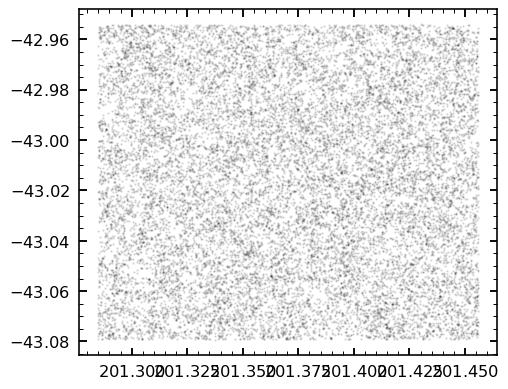

In [59]:
flag = cat['star_flag']
plt.scatter(cat[flag]['ra'], cat[flag]['dec'], s=1, c='k', alpha=0.1)

Text(0, 0.5, 'Dec')

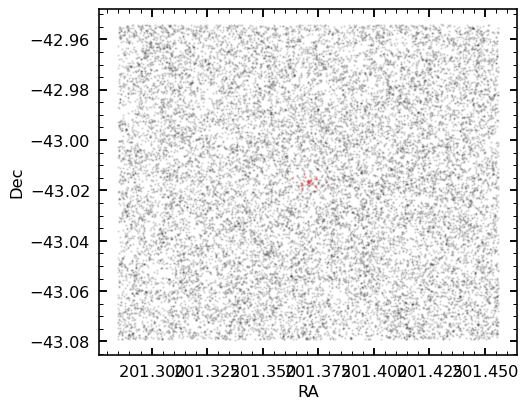

In [18]:
plt.scatter(cat['ra'], cat['dec'], s=1, c='k', alpha=0.1)
# plt.scatter(cat['ra'][inside], cat['dec'][inside], s=1, c='k', alpha=0.3)

flag = -2.5 * np.log10(gal.obj_cat['F158']) < 27
plt.scatter(gal.obj_cat['ra'][flag], gal.obj_cat['dec'][flag], s=1, c='r', ec='r', alpha=0.3)

plt.xlabel('RA')
plt.ylabel('Dec')

In [42]:
from rosesim import ripples_completeness_dict, ripples_mag_uncertainty_dict
from ripples.utils import setup_dolphot_cat, apply_obs_model_two_band

In [52]:
rng = np.random.default_rng(123)
depth_HLWAS = 1

ufd = gal.obj_cat

# Ultra-faint dwarf sources
ufd = apply_obs_model_two_band(
    -2.5 * np.log10(ufd["F106"]), 
    -2.5 * np.log10(ufd["F158"]),
    bands=['F106', 'F158'],
    completeness_dict=ripples_completeness_dict['3.5Mpc'],
    mag_uncertainty_dict=ripples_mag_uncertainty_dict['3.5Mpc'],
    rng=rng,
    detection="both",     # since you care about colors
    depth_HLWAS=depth_HLWAS
)
ufd['MC_SOURCE_ID'] = gal.obj_cat['label']
ufd['RA'] = gal.obj_cat['ra']
ufd['DEC'] = gal.obj_cat['dec']

dol = setup_dolphot_cat(cat)

(30.0, 20.0)

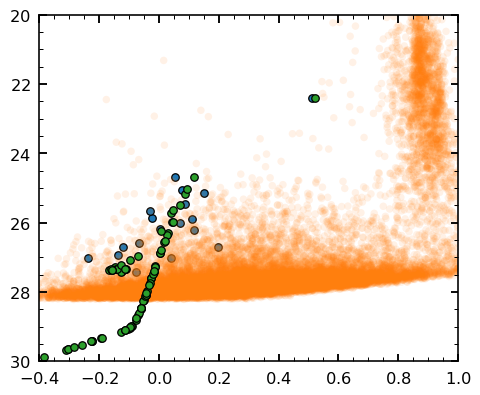

In [53]:
plt.scatter(ufd['MAG_DERED_F106'] - ufd['MAG_DERED_F158'], ufd['MAG_DERED_F158'])
flag = dol['star_flag']
plt.scatter(dol[flag]['MAG_DERED_F106'] - dol[flag]['MAG_DERED_F158'], dol[flag]['MAG_DERED_F158'], alpha=0.1, ec='none')
plt.scatter(-2.5 * np.log10(gal.obj_cat['F106'] / gal.obj_cat['F158']), -2.5*np.log10(gal.obj_cat['F158']))
plt.xlim(-0.4, 1)
plt.ylim(30, 20)

In [54]:
full_cat = np.concatenate([ufd, dol])
full_cat = full_cat[~(np.isnan(full_cat['MAG_F106']) | np.isnan(full_cat['MAG_F158']))]

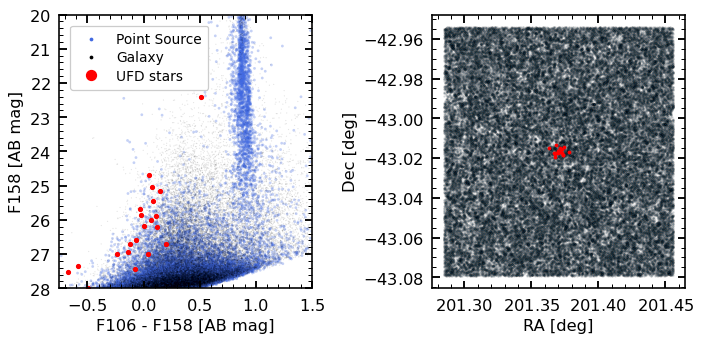

In [55]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 4))
plt.sca(ax1)

qa_flag = full_cat['star_flag']
plt.scatter((full_cat['MAG_DERED_F106'] - full_cat['MAG_DERED_F158'])[qa_flag], 
            full_cat['MAG_DERED_F158'][qa_flag], s=5, alpha=0.3, color='royalblue', ec='none', label='Point Source')

qa_flag = full_cat['quality_flag'] & (~full_cat['star_flag'])
plt.scatter((full_cat['MAG_DERED_F106'] - full_cat['MAG_DERED_F158'])[qa_flag], 
            full_cat['MAG_DERED_F158'][qa_flag], color='k', ec='none', s=1, alpha=0.1, label='Galaxy')

flag = full_cat['MC_SOURCE_ID'] == 1 # UFD stars
plt.scatter(full_cat[flag]['MAG_DERED_F106'] - full_cat[flag]['MAG_DERED_F158'], 
            full_cat[flag]['MAG_DERED_F158'], s=10, ec='r', fc='r', label='UFD stars')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='royalblue', markeredgecolor='none',
           markersize=3, label='Point Source'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='k', markeredgecolor='none',
           markersize=3, label='Galaxy'),
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor='r', markeredgecolor='r',
           markersize=8, label='UFD stars')
]
plt.legend(handles=legend_elements, frameon=True, fontsize=11)
plt.ylim(28, 20)
plt.xlim(-0.75, 1.5)
plt.xlabel('F106 - F158 [AB mag]')
plt.ylabel('F158 [AB mag]')

plt.sca(ax2)
plt.scatter(full_cat['RA'], full_cat['DEC'], s=1, alpha=0.1)
plt.scatter(full_cat[flag]['RA'], full_cat[flag]['DEC'], s=4, ec='r', fc='r')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

plt.tight_layout()

In [57]:
gal.prefix

'dw_1e4.0_3.0Mpc_age9.6_feh-2.0'

'dw_1e4.0_3.0Mpc_age9.6_feh-2.0'

In [316]:
setup_data.split_by_healpix(full_cat, output_dir='/home/jiaxuanl/Research/Packages/simple/example/data')

Splitting data by HEALPix (nside=32)...
Wrote 12116 stars to /home/jiaxuanl/Research/Packages/simple/example/data/data_08644.fits
Wrote 61693 stars to /home/jiaxuanl/Research/Packages/simple/example/data/data_08772.fits


In [ ]:
src.r_sky / 60

In [318]:
result = np.load('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/SIMPLE/gals/dw_1e4.2_3.0Mpc_age9.6_feh-2.0/simple_output.npy')

In [323]:
result['R'] * 60

array([2.68333333])

In [326]:
11 * 13

143

np.float64(201.28478345792192)

Text(0, 0.5, 'F158 [AB mag]')

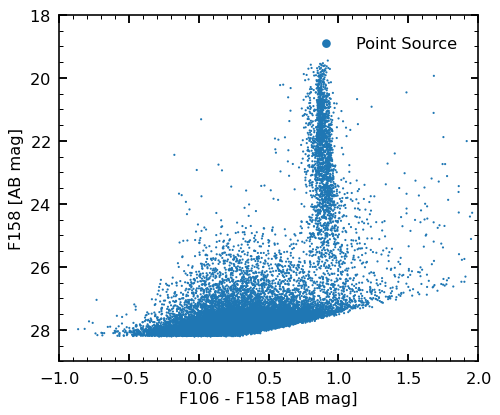

In [81]:
flag = cat['star_flag']
plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
            ec='none', s=3, label='Point Source')


plt.xlim(-1., 2)
plt.ylim(29, 18)
plt.xlim()
plt.legend(markerscale=4.0)
plt.xlabel('F106 - F158 [AB mag]')
plt.ylabel('F158 [AB mag]')

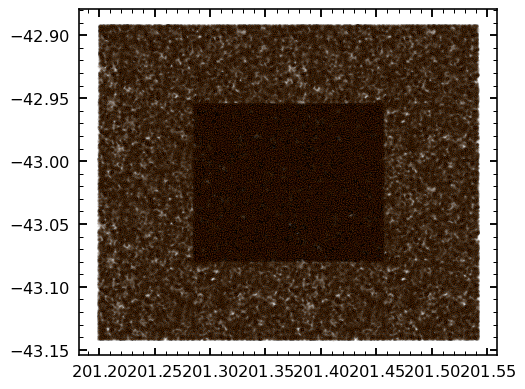

In [74]:
plt.scatter(cat['ra'], cat['dec'], s=1, c='k', alpha=0.1)
plt.scatter(temp['ra'], temp['dec'], s=1, c='C1', alpha=0.1)

In [80]:
## Tile the background
from astropy.coordinates import SkyCoord, SkyOffsetFrame
def tile_catalog_radec(cat, tile_nx, tile_ny, 
                       ra_col='ra', dec_col='dec', center=None,
                       jitter_arcsec=0.0, seed=0):
    """
    Tile a small RA/Dec catalog into a larger footprint by repeating it on a TAN plane.

    Parameters
    ----------
    cat : astropy.table.Table (or dict-like with numpy arrays)
    tile_nx, tile_ny : int
        Number of tiles in x (roughly RA direction) and y (Dec direction).
        Total copies = tile_nx * tile_ny.
    Lx_arcmin, Ly_arcmin : float
        Tile size in arcmin (your original patch size).
    center : (ra0, dec0) in degrees, optional
        Tangent point. If None, uses the median RA/Dec of the input catalog.
    jitter_arcsec : float
        Optional small random jitter applied to duplicated sources to hide seams.
    """
    rng = np.random.default_rng(seed)

    ra = np.array(cat[ra_col], dtype=float)
    dec = np.array(cat[dec_col], dtype=float)

    Lx_arcmin = (ra.max() - ra.min()) * np.cos(np.deg2rad(dec.mean())) * 60
    Ly_arcmin = (dec.max() - dec.min()) * 60
    print(Lx_arcmin, Ly_arcmin)

    if center is None:
        ra0 = np.median(ra)
        dec0 = np.median(dec)
    else:
        ra0, dec0 = center

    origin = SkyCoord(ra0*u.deg, dec0*u.deg, frame="icrs")
    off_frame = SkyOffsetFrame(origin=origin)

    c = SkyCoord(ra*u.deg, dec*u.deg, frame="icrs")
    c_off = c.transform_to(off_frame)

    # Local tangent-plane coordinates (small-angle offsets) in degrees
    x = c_off.lon.to_value(u.deg)   # "x" direction on plane
    y = c_off.lat.to_value(u.deg)   # "y" direction on plane

    Lx = (Lx_arcmin * u.arcmin).to_value(u.deg)
    Ly = (Ly_arcmin * u.arcmin).to_value(u.deg)

    # Build shifts: center tiles around (0,0)
    ix = np.arange(tile_nx) - (tile_nx - 1)/2
    iy = np.arange(tile_ny) - (tile_ny - 1)/2
    dx_grid, dy_grid = np.meshgrid(ix * Lx, iy * Ly, indexing="xy")
    dx_list = dx_grid.ravel()
    dy_list = dy_grid.ravel()

    # Replicate points
    x_big = np.concatenate([x + dx for dx in dx_list])
    y_big = np.concatenate([y + dy for dy in dy_list])

    if jitter_arcsec and jitter_arcsec > 0:
        sig = (jitter_arcsec * u.arcsec).to_value(u.deg)
        x_big += rng.normal(0.0, sig, size=x_big.size)
        y_big += rng.normal(0.0, sig, size=y_big.size)

    # Map back to RA/Dec
    c_big_off = SkyCoord(lon=x_big*u.deg, lat=y_big*u.deg, frame=off_frame)
    c_big = c_big_off.transform_to("icrs")

    ra_new = c_big.ra.wrap_at(360*u.deg).to_value(u.deg)
    dec_new = c_big.dec.to_value(u.deg)

    # Return a copy with updated coordinates
    out = cat.copy()
    # If you want to preserve other columns, replicate full rows:
    # (do this if cat is an astropy Table)
    try:
        out = np.repeat(cat, tile_nx*tile_ny)  # works for Table
    except Exception:
        pass

    out[ra_col] = ra_new
    out[dec_col] = dec_new
    return out

In [82]:
cat_tiled = tile_catalog_radec(cat, 3, 3,)

7.512092442912923 7.508390375221694


In [83]:
Table(cat_tiled).write('/scratch/gpfs/JENNYG/jiaxuanl/Data/Roman/UFD_detection/cena_3000s.tiled.phot.csv')

In [84]:
del cat_tiled

## Check SIMPLE results

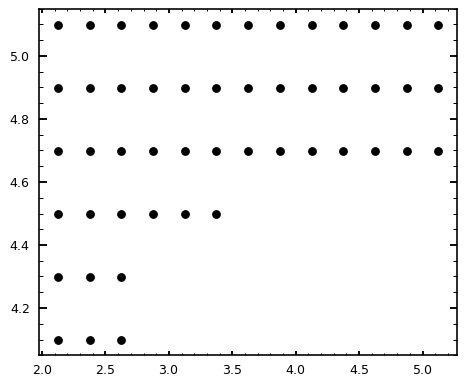

In [345]:
logm_grid = np.array([3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2, 4.4, 4.6, 4.8, 5.0]) + 0.1
dist_grid = np.array([2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0]) + 0.125
DATA_PATH = os.path.join(os.environ['ROSESIM_DATA_PATH'], 'SIMPLE', 'gals')
log_age, feh = 9.6, -2
input_coord = SkyCoord(11.8880580, -25.28, unit='deg')

for logm in logm_grid:
    for dist in dist_grid:
        prefix = f'dw_1e{logm:.1f}_{dist:.1f}Mpc_age{log_age:.1f}_feh{feh:.1f}'
        result = np.load(os.path.join(DATA_PATH, prefix, 'simple_output.npy'))
        coord = SkyCoord(result['RA'], result['DEC'], unit='deg')
        sep = coord.separation(input_coord)
        if np.min(sep) < 1 * u.arcmin:
            # print(prefix)
            plt.scatter(dist, logm, color='k')

### Run SIMPLE

In [104]:
os.chdir('/home/jiaxuanl/Research/Packages/simple/simple_example/')

In [119]:
import simple.plotting.diagnostic_plots

In [116]:
data, iso, g_radius, nbhd = simple.plotting.diagnostic_plots.analysis(obs_ra, obs_dec, 27.0, 0)

mode = 0: running only on real data
Loading data...
Assembling data...
Found 6161 objects...


0.010307807807807807 half_point


/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/scratch/gpfs/LSST/stacks/stack_20250106/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


array([False, False, False, ..., False, False, False], shape=(6161,))

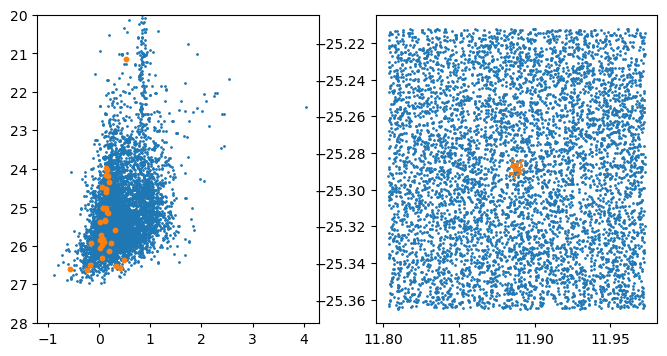

In [128]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 4))
plt.sca(ax1)

plt.scatter(data['MAG_DERED_F106'] - data['MAG_DERED_F158'], data['MAG_DERED_F158'], s=1)

flag = data['MC_SOURCE_ID'] == 1 # UFD stars
plt.scatter(data[flag]['MAG_DERED_F106'] - data[flag]['MAG_DERED_F158'], data[flag]['MAG_DERED_F158'], s=10)
plt.ylim(28, 20)

plt.sca(ax2)
plt.scatter(data['RA'], data['DEC'], s=1)
plt.scatter(data[flag]['RA'], data[flag]['DEC'], s=1)
# plt.scatter(data[nbhd]['RA'], data[nbhd]['DEC'], s=1)

# delta = 0.1
# plt.xlim(90-delta, 90+delta)
# plt.ylim(-delta, delta)

In [138]:
4096 * 0.11 / 3600 / 2

0.06257777777777777

In [142]:
0.01 * (0.25 * np.arctan(0.25*g_radius*60. - 1.5) + 1.3) * 3600

np.float64(38.41552724168044)

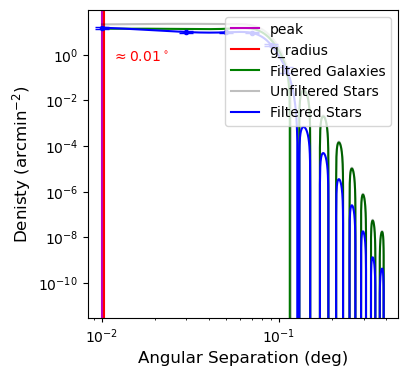

In [152]:
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
# simple.plotting.diagnostic_plots.density_plot(axes, obs_ra, obs_dec, data, iso, g_radius, nbhd, 'galaxies')
simple.plotting.diagnostic_plots.radial_plot(axes, obs_ra, obs_dec, data, iso, g_radius, nbhd)

# axes.scatter(data['RA'] - obs_ra, data['DEC'] - obs_dec, s=1, zorder=1)
# plt.scatter(data[flag]['RA'], data[flag]['DEC'], s=1)

<unknown>:259: SyntaxWarning: invalid escape sequence '\p'
<unknown>:262: SyntaxWarning: invalid escape sequence '\D'
<unknown>:259: SyntaxWarning: invalid escape sequence '\p'
<unknown>:262: SyntaxWarning: invalid escape sequence '\D'
/home/jiaxuanl/Research/Packages/simple/simple/plotting/diagnostic_plots.py:259: SyntaxWarning: invalid escape sequence '\p'
  ax.scatter(data[mag_dered_1][filter & nbhd] - data[mag_dered_2][filter & nbhd], data[mag_dered_1][filter & nbhd], c='g', s=5, label='r < {:.3f}$^\prime$'.format(g_radius * 60))
/home/jiaxuanl/Research/Packages/simple/simple/plotting/diagnostic_plots.py:262: SyntaxWarning: invalid escape sequence '\D'
  ax.scatter(data[mag_dered_1][filter & nbhd & iso_filter] - data[mag_dered_2][filter & nbhd & iso_filter], data[mag_dered_1][filter & nbhd & iso_filter], c='r', s=5, label='$\Delta$CM < 0.1')


AttributeError: 'Isochrone' object has no attribute 'stage'

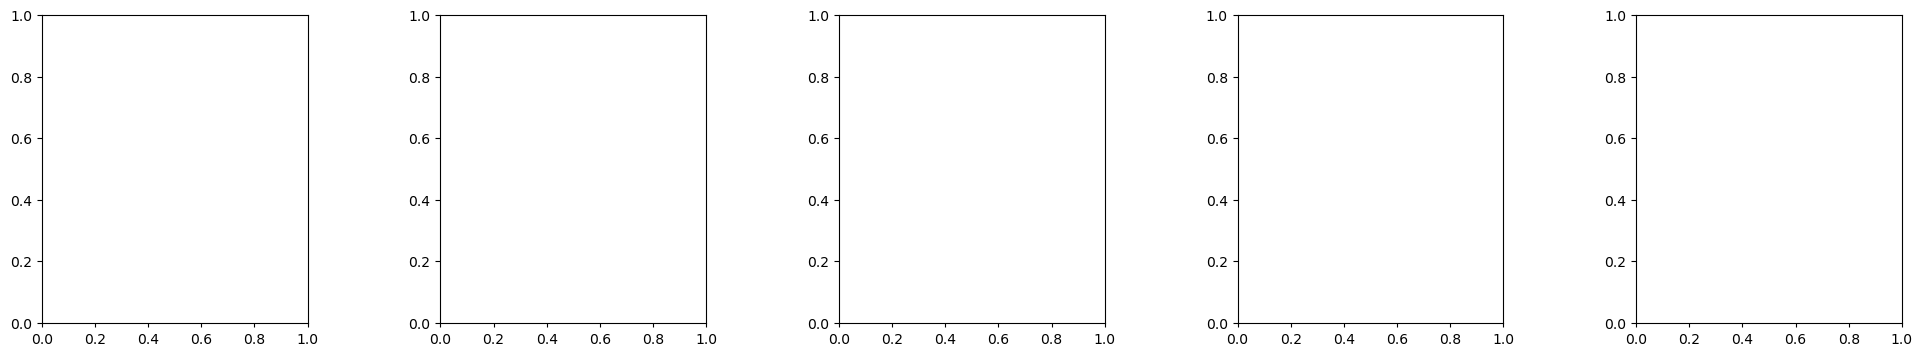

In [205]:
fig, axs = plt.subplots(1, 5, figsize=(24, 4))
fig.subplots_adjust(wspace=0.5, hspace=0.5)

simple.plotting.diagnostic_plots.star_plot(axs[0], obs_ra, obs_dec, data, iso, g_radius, nbhd)
simple.plotting.diagnostic_plots.density_plot(axs[1], obs_ra, obs_dec, data, iso, g_radius, nbhd, 'stars')
simple.plotting.diagnostic_plots.density_plot(axs[2], obs_ra, obs_dec, data, iso, g_radius, nbhd, 'galaxies')
simple.plotting.diagnostic_plots.cm_plot(axs[3], obs_ra, obs_dec, data, iso, g_radius, nbhd, 'stars')
simple.plotting.diagnostic_plots.hess_plot(axs[4], obs_ra, obs_dec, data, iso, g_radius, nbhd)

In [ ]:
import sys
import os
import shutil
import yaml
import numpy as np
import healpy as hp

# Add the 'simple' package to path
sys.path.append('/home/jiaxuanl/Research/Packages/simple')

# SIMPLE requires 'config.yaml' to be in the CWD (current working directory), 
# so we change to the example directory where our config is BEFORE importing simple_utils
os.chdir('/home/jiaxuanl/Research/Packages/simple/simple_example')

# Import simple modules
import simple.simple_utils
import simple.filters

# Load config to get nside and other params
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

survey = config['survey']
nside = config[survey]['nside']
mag_max = config[survey]['mag_max']

# Target coordinates (Cluster location injected in setup_data.py)
ra_select = 90
dec_select = 0.0
print(f"Searching around RA={ra_select}, Dec={dec_select}")

# Find helper pixel
pix_nside_select = hp.ang2pix(nside, ra_select, dec_select, lonlat=True)
print(f"Target Healpix: {pix_nside_select}")

# Distance modulus to search (150 kpc ~ 20.9 mag)
# We will search a range
distance_modulus_search = np.arange(23.0, 27.0, 0.5)

# Load data using simple_utils
# simple_utils.construct_real_data needs pix_nside_neighbors
pix_nside_neighbors = np.concatenate([[pix_nside_select], hp.get_all_neighbours(nside, pix_nside_select)])
print(f"Loading data for pixels: {pix_nside_neighbors}")

data = simple.simple_utils.construct_real_data(pix_nside_neighbors)
print(f"Loaded {len(data)} objects.")

# Deredden (MWE has no extinction, but pipeline expects this step)
# In our config we set MAG_DERED_X = MAG_X, so this is just copying
data = simple.filters.dered_mag(survey, data)

In [ ]:
# flag = cat['MAG_DERED_G'] 
plt.scatter(data['RA'], data['DEC'], s=1)
# plt.scatter(data['RA'][cut], data['DEC'][cut], s=1)

delta = 0.1
plt.xlim(90-delta, 90+delta)
plt.ylim(-delta, delta)

plt.scatter(results[0], results[1], marker='+')

In [ ]:
distance_modulus_search

In [ ]:
print("Starting search...")

ra_peak_array = []
dec_peak_array = [] 
r_peak_array = []
sig_peak_array = []
distance_modulus_array = []
mc_source_id_array = []
n_obs_peak_array = []
n_obs_half_peak_array = []
n_model_peak_array = []

for distance_modulus in distance_modulus_search:
    ra_peaks, dec_peaks, r_peaks, sig_peaks, dist_moduli, n_obs_peaks, n_obs_half_peaks, n_model_peaks = simple.simple_utils.search_by_distance(nside, data, distance_modulus, pix_nside_select, ra_select, dec_select, mag_max, None)
    ra_peak_array.append(ra_peaks)
    dec_peak_array.append(dec_peaks)
    r_peak_array.append(r_peaks)
    sig_peak_array.append(sig_peaks)
    distance_modulus_array.append(dist_moduli)
    n_obs_peak_array.append(n_obs_peaks)
    n_obs_half_peak_array.append(n_obs_half_peaks)
    n_model_peak_array.append(n_model_peaks)
    mc_source_id_array.append(np.tile(0, len(sig_peaks)))

ra_peak_array = np.concatenate(ra_peak_array)
dec_peak_array = np.concatenate(dec_peak_array)
r_peak_array = np.concatenate(r_peak_array)
sig_peak_array = np.concatenate(sig_peak_array)
distance_modulus_array = np.concatenate(distance_modulus_array)
n_obs_peak_array = np.concatenate(n_obs_peak_array)
n_obs_half_peak_array = np.concatenate(n_obs_half_peak_array)
n_model_peak_array = np.concatenate(n_model_peak_array)
mc_source_id_array = np.concatenate(mc_source_id_array)

In [ ]:
# sort by significance
index_sort = np.argsort(sig_peak_array)[::-1]
ra_peak_array = ra_peak_array[index_sort]
dec_peak_array = dec_peak_array[index_sort]
r_peak_array = r_peak_array[index_sort]
sig_peak_array = sig_peak_array[index_sort]
distance_modulus_array = distance_modulus_array[index_sort]
n_obs_peak_array = n_obs_peak_array[index_sort]
n_obs_half_peak_array = n_obs_half_peak_array[index_sort]
n_model_peak_array = n_model_peak_array[index_sort]
mc_source_id_array = mc_source_id_array[index_sort]

In [ ]:
# Collect overlapping peaks
for ii in range(0, len(sig_peak_array)):
    # if sig_peak_array[ii] < 0:
    #     continue
    angsep = ugali.utils.projector.angsep(ra_peak_array[ii], dec_peak_array[ii], ra_peak_array, dec_peak_array)
    sig_peak_array[(angsep < r_peak_array[ii]) & (np.arange(len(sig_peak_array)) > ii)] = -1.
    #sig_peak_array[(angsep < 0.5) & (np.arange(len(sig_peak_array)) > ii)] = -1. # 0.5 deg radius

In [ ]:
# Prune the list of peaks
ra_peak_array = ra_peak_array[sig_peak_array > 0.]
dec_peak_array = dec_peak_array[sig_peak_array > 0.]
r_peak_array = r_peak_array[sig_peak_array > 0.]
distance_modulus_array = distance_modulus_array[sig_peak_array > 0.]
n_obs_peak_array = n_obs_peak_array[sig_peak_array > 0.]
n_obs_half_peak_array = n_obs_half_peak_array[sig_peak_array > 0.]
n_model_peak_array = n_model_peak_array[sig_peak_array > 0.]
mc_source_id_array = mc_source_id_array[sig_peak_array > 0.]
sig_peak_array = sig_peak_array[sig_peak_array > 0.] # Update the sig_peak_array last!

for ii in range(0, len(sig_peak_array)):
    print('{:0.2f} sigma; (RA, Dec, d) = ({:0.2f}, {:0.2f}); r = {:0.2f} deg; d = {:0.1f}, mu = {:0.2f} mag), mc_source_id: {:0.2f}'.format(sig_peak_array[ii], 
                 ra_peak_array[ii], 
                 dec_peak_array[ii], 
                 r_peak_array[ii],
                 ugali.utils.projector.distanceModulusToDistance(distance_modulus_array[ii]),
                 distance_modulus_array[ii],
                 mc_source_id_array[ii]))

In [ ]:
# flag = cat['MAG_DERED_G'] 
plt.scatter(data['RA'], data['DEC'], s=1)

delta = 0.1
plt.xlim(90-delta, 90+delta)
plt.ylim(-delta, delta)

plt.scatter(90.73, -0.58, marker='+', color='r')

In [ ]:
print("Starting search...")
for distance_modulus in distance_modulus_search:
    results = simple.simple_utils.search_by_distance(
        nside, data, distance_modulus, pix_nside_select, 
        ra_select, dec_select, 25.0
    )

    # Unpack results: ra_peaks, dec_peaks, r_peaks, sig_peaks, ...
    sig_peaks = results[3]
    if len(sig_peaks) > 0:
        print(f"DistMod {distance_modulus}: Found {len(sig_peaks)} peaks. Max Sig: {np.max(sig_peaks):.2f}")

## Isochrone

(28.0, 20.0)

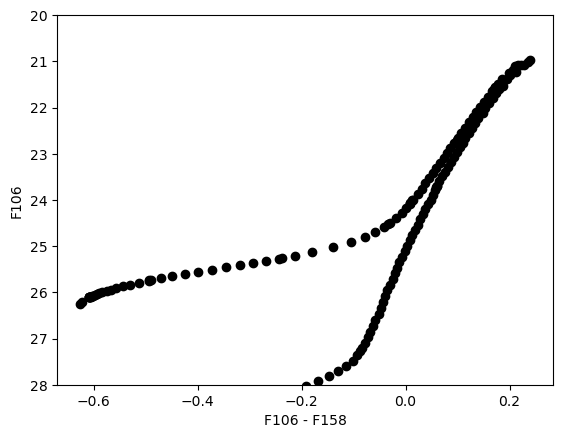

In [8]:
import ugali
import ugali.isochrone
iso = ugali.isochrone.factory(name='Bressan2012', survey='roman', band_1='F106', band_2='F158')
iso.age = 12.
iso.metallicity = 0.0001
iso.distance_modulus = 25.0

# cut = simple.simple_utils.cut_isochrone_path(data['MAG_DERED_G'], data['MAG_DERED_R'], data['MAG_ERR_G'], data['MAG_ERR_R'], iso, radius=0.1)
# cut = simple.simple_utils.cut_isochrone_path(data['MAG_DERED_G'], data['MAG_DERED_R'], np.zeros(len(data)), np.zeros(len(data)), iso, radius=0.01)

def plot_iso(iso):
    plt.scatter(iso.mag_1-iso.mag_2,iso.mag_1+iso.distance_modulus,marker='o',c='k')
    plt.gca().invert_yaxis()
    plt.xlabel('%s - %s'%(iso.band_1,iso.band_2)); plt.ylabel(iso.band_1)

# plt.scatter(data['MAG_DERED_G'] - data['MAG`_DERED_R'], data['MAG_DERED_R'], s=1)
# plt.scatter(data[cut]['MAG_DERED_G'] - data[cut]['MAG_DERED_R'], data[cut]['MAG_DERED_R'], s=1)
plot_iso(iso)
plt.ylim(28, 20)